<a href="https://colab.research.google.com/github/nazianusrat/Insta-shield-2025/blob/main/Copy_of_Screen_time_reduction_what_works.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sources:

1. Bar chart with individual bar colors https://matplotlib.org/stable/gallery/lines_bars_and_markers/bar_colors.html
2. light background gridlines
Adds subtle horizontal gridlines to make bar heights easier to read.
https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
3.  to create a figure and axes in matplotlib : https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.bar.html
4. Used to place d ≈ value text above each bar by getting the bar's position with bar.get_x() and bar.get_height() https://matplotlib.org/3.6.3/gallery/lines_bars_and_markers/bar_label_demo.html

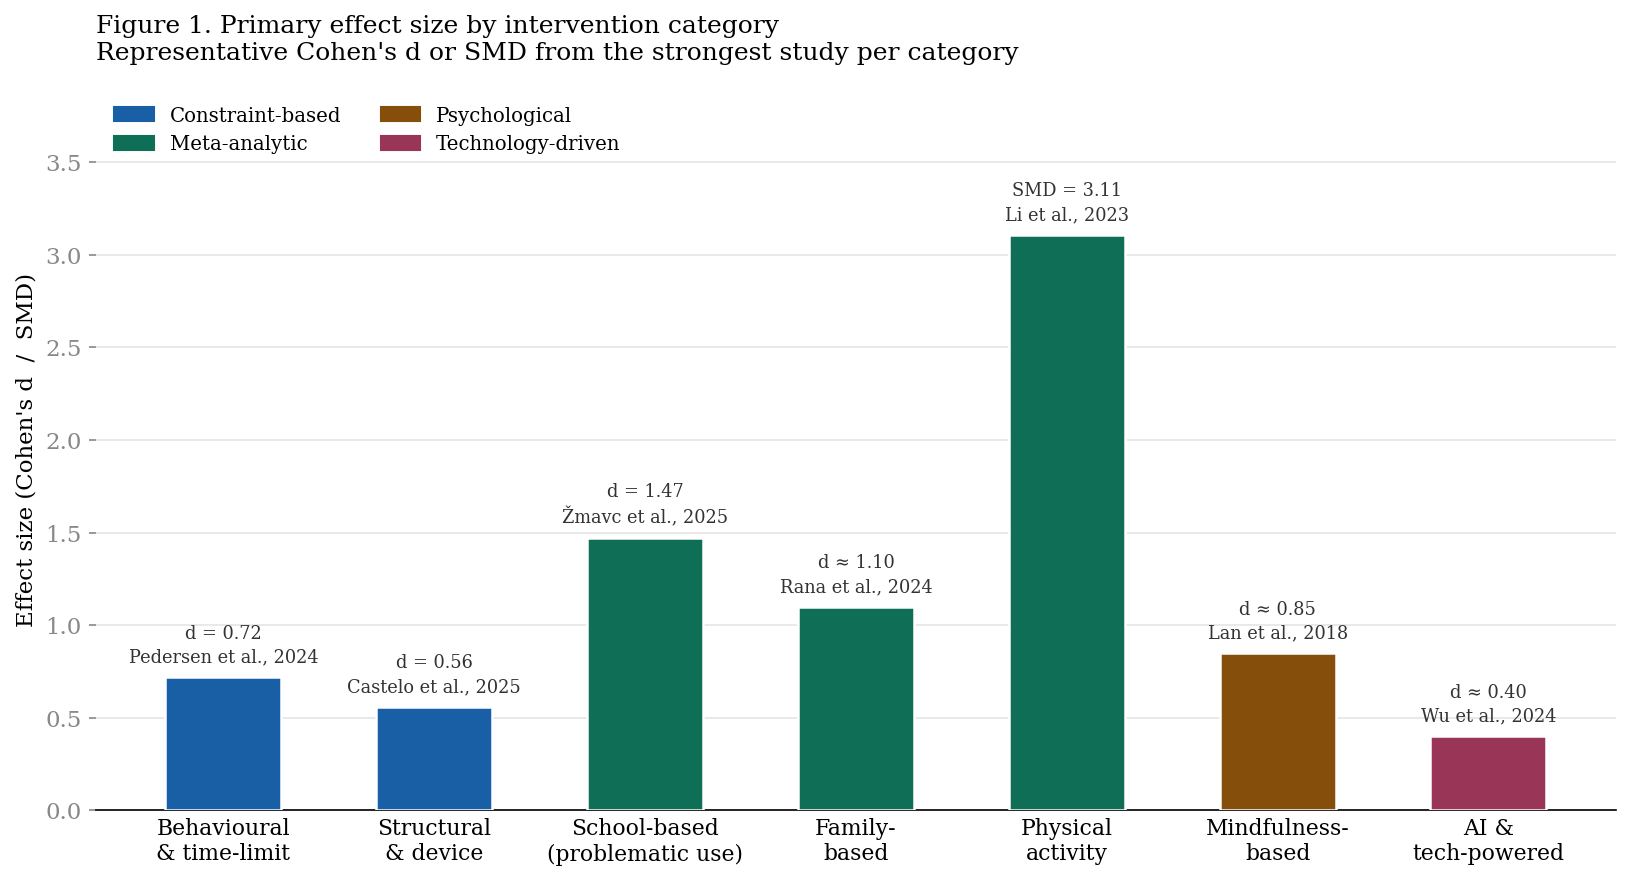

Saved: figure1_effect_sizes.png


In [ ]:


import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


plt.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#E5E5E5',
    'grid.linewidth': 0.8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})


BLUE   = '#185FA5'   # constraint-based
GREEN  = '#0F6E56'   # meta-analytic
AMBER  = '#854F0B'   # psychological
PINK   = '#993556'   # technology
LIGHT  = '#EBF3FB'   # bar face fill (light version of blue)

categories = [
    'Behavioural\n& time-limit',
    'Structural\n& device',
    'School-based\n(problematic use)',
    'Family-\nbased',
    'Physical\nactivity',
    'Mindfulness-\nbased',
    'AI &\ntech-powered',
]

effects = [0.72, 0.56, 1.47, 1.10, 3.11, 0.85, 0.40]

bar_colors = [BLUE, BLUE, GREEN, GREEN, GREEN, AMBER, PINK]

annotations = [
    'd = 0.72\nPedersen et al., 2024',
    'd = 0.56\nCastelo et al., 2025',
    'd = 1.47\nŽmavc et al., 2025',
    'd ≈ 1.10\nRana et al., 2024',
    'SMD = 3.11\nLi et al., 2023',
    'd ≈ 0.85\nLan et al., 2018',
    'd ≈ 0.40\nWu et al., 2024',
]

fig1, ax1 = plt.subplots(figsize=(11, 6))

x = np.arange(len(categories))
bars = ax1.bar(x, effects, color=bar_colors, width=0.55,
               edgecolor='white', linewidth=1.2, zorder=3)

# Value labels above each bar
for bar, val, ann in zip(bars, effects, annotations):
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.06,
             ann,
             ha='center', va='bottom', fontsize=8.5,
             color='#333333', linespacing=1.4)

ax1.set_xticks(x)
ax1.set_xticklabels(categories, fontsize=10.5)
ax1.set_ylabel("Effect size (Cohen's d  /  SMD)", fontsize=11)
ax1.set_ylim(0, 3.9)
ax1.tick_params(axis='x', length=0)
ax1.tick_params(axis='y', colors='#888888')
ax1.yaxis.grid(True, color='#E5E5E5', linewidth=0.8, zorder=0)
ax1.set_axisbelow(True)

# Legend
legend_handles = [
    mpatches.Patch(color=BLUE,  label='Constraint-based'),
    mpatches.Patch(color=GREEN, label='Meta-analytic'),
    mpatches.Patch(color=AMBER, label='Psychological'),
    mpatches.Patch(color=PINK,  label='Technology-driven'),
]
ax1.legend(handles=legend_handles, loc='upper left',
           frameon=False, fontsize=9.5, ncol=2)

ax1.set_title(
    'Figure 1. Primary effect size by intervention category\n'
    'Representative Cohen\'s d or SMD from the strongest study per category',
    fontsize=12, fontweight='normal', pad=14, loc='left'
)

plt.tight_layout()
plt.savefig('figure1_effect_sizes.png')
plt.show()
print("Saved: figure1_effect_sizes.png")



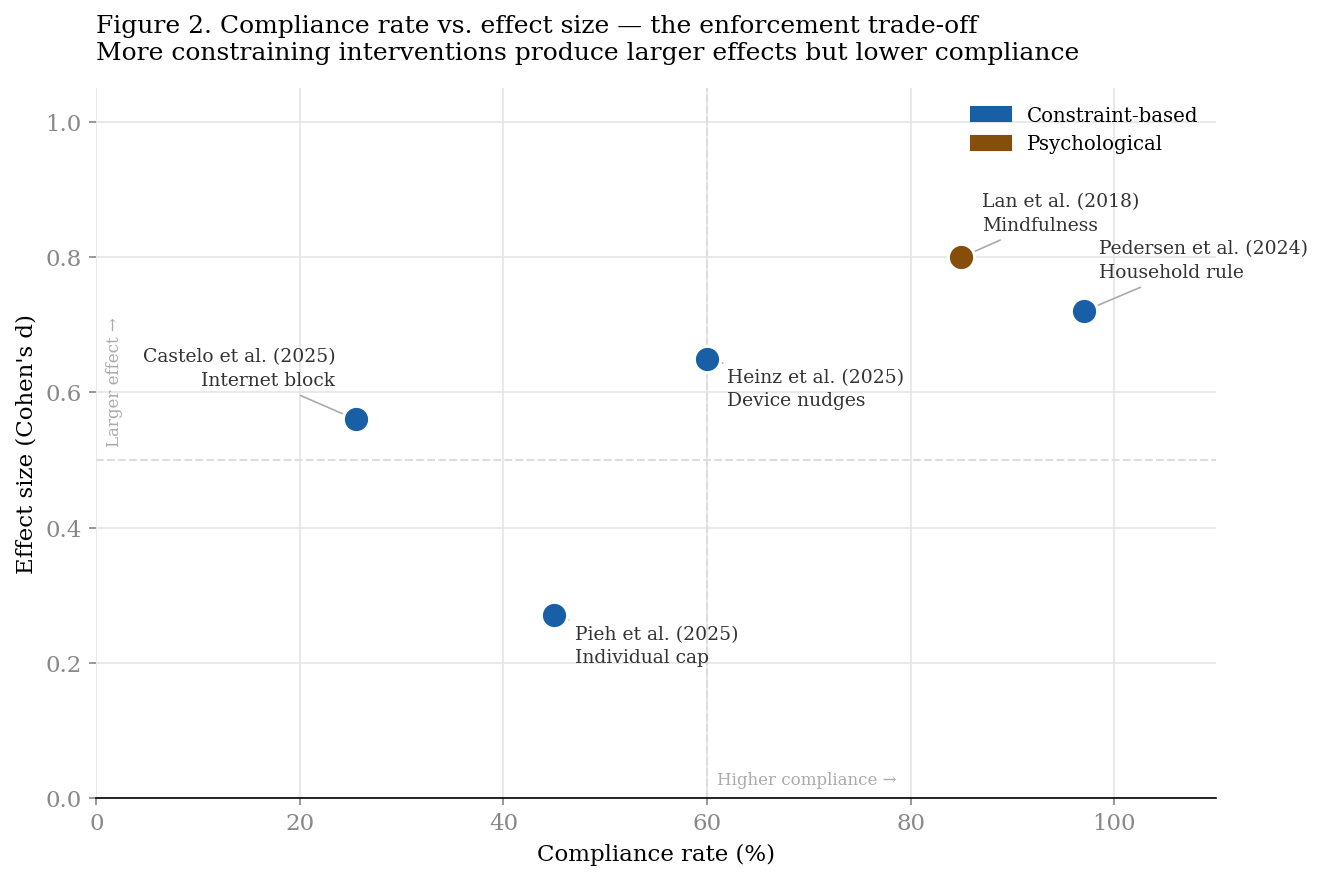

Saved: figure2_compliance_vs_effect.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np


plt.rcParams.update({
    'font.family': 'DejaVu Serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.spines.left': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.color': '#E5E5E5',
    'grid.linewidth': 0.8,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})


BLUE   = '#185FA5'   # constraint-based
GREEN  = '#0F6E56'   # meta-analytic
AMBER  = '#854F0B'   # psychological
PINK   = '#993556'   # technology
LIGHT  = '#EBF3FB'   # bar face fill (light version of blue)

studies = [
    {'label': 'Pedersen et al. (2024)\nHousehold rule',   'x': 97,   'y': 0.72, 'c': BLUE},
    {'label': 'Pieh et al. (2025)\nIndividual cap',       'x': 45,   'y': 0.27, 'c': BLUE},
    {'label': 'Castelo et al. (2025)\nInternet block',    'x': 25.5, 'y': 0.56, 'c': BLUE},
    {'label': 'Lan et al. (2018)\nMindfulness',           'x': 85,   'y': 0.80, 'c': AMBER},
    {'label': 'Heinz et al. (2025)\nDevice nudges',       'x': 60,   'y': 0.65, 'c': BLUE},
]


label_offsets = [
    ( 1.5,  0.05),   # Pedersen — top right
    ( 2,   -0.07),   # Pieh     — below
    (-2,    0.05),   # Castelo  — left
    ( 2,    0.04),   # Lan      — right
    ( 2,   -0.07),   # Heinz    — below right
]

fig2, ax2 = plt.subplots(figsize=(9, 6))

for s, (dx, dy) in zip(studies, label_offsets):
    ax2.scatter(s['x'], s['y'], s=160, color=s['c'],
                edgecolors='white', linewidths=1.5, zorder=5)
    ax2.annotate(
        s['label'],
        xy=(s['x'], s['y']),
        xytext=(s['x'] + dx, s['y'] + dy),
        fontsize=9, color='#333333', linespacing=1.4,
        ha='left' if dx >= 0 else 'right',
        arrowprops=dict(arrowstyle='-', color='#AAAAAA', lw=0.8),
    )

ax2.set_xlabel('Compliance rate (%)', fontsize=11)
ax2.set_ylabel("Effect size (Cohen's d)", fontsize=11)
ax2.set_xlim(0, 110)
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='both', colors='#888888')
ax2.yaxis.grid(True, color='#E5E5E5', linewidth=0.8, zorder=0)
ax2.set_axisbelow(True)
ax2.xaxis.grid(True, color='#E5E5E5', linewidth=0.8, zorder=0)


ax2.axvline(60, color='#DDDDDD', lw=1, ls='--', zorder=1)
ax2.axhline(0.5, color='#DDDDDD', lw=1, ls='--', zorder=1)
ax2.text(61, 0.02, 'Higher compliance →', fontsize=8, color='#AAAAAA')
ax2.text(1, 0.52, 'Larger effect →', fontsize=8, color='#AAAAAA', rotation=90, va='bottom')

legend_handles2 = [
    mpatches.Patch(color=BLUE,  label='Constraint-based'),
    mpatches.Patch(color=AMBER, label='Psychological'),
]
ax2.legend(handles=legend_handles2, frameon=False, fontsize=9.5)

ax2.set_title(
    'Figure 2. Compliance rate vs. effect size — the enforcement trade-off\n'
    'More constraining interventions produce larger effects but lower compliance',
    fontsize=12, fontweight='normal', pad=14, loc='left'
)

plt.tight_layout()
plt.savefig('figure2_compliance_vs_effect.png')
plt.show()
print("Saved: figure2_compliance_vs_effect.png")


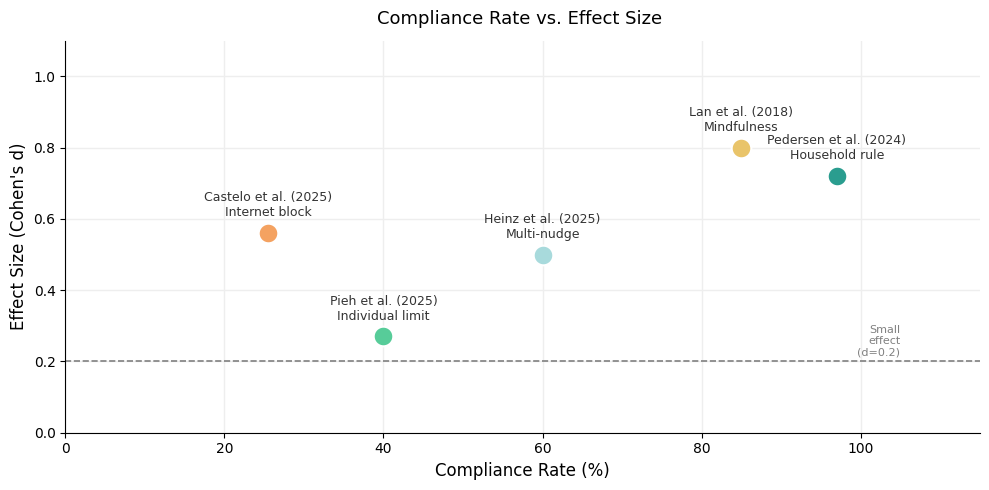

In [ ]:
import matplotlib.pyplot as plt

# Data
studies2 = {
    "Pedersen et al. (2024)\nHousehold rule":  {"compliance": 97,   "effect": 0.72, "color": "#2a9d8f"},
    "Pieh et al. (2025)\nIndividual limit":    {"compliance": 40,   "effect": 0.27, "color": "#57cc99"},
    "Castelo et al. (2025)\nInternet block":   {"compliance": 25.5, "effect": 0.56, "color": "#f4a261"},
    "Lan et al. (2018)\nMindfulness":          {"compliance": 85,   "effect": 0.80, "color": "#e9c46a"},
    "Heinz et al. (2025)\nMulti-nudge":        {"compliance": 60,   "effect": 0.50, "color": "#a8dadc"},
}

fig2, ax = plt.subplots(figsize=(10, 5))

for study, data in studies2.items():
    ax.scatter(data["compliance"], data["effect"],
               color=data["color"],
               s=200,
               zorder=5,
               edgecolors='white',
               linewidths=1.5)
    ax.annotate(study,
                xy=(data["compliance"], data["effect"]),
                xytext=(0, 12),
                textcoords='offset points',
                ha='center', fontsize=9, color='#333333')


ax.axhline(y=0.2, color='gray', linestyle='--', linewidth=1.2)
ax.text(105, 0.21, "Small\neffect\n(d=0.2)",
        fontsize=8, color='gray', va='bottom', ha='right')

ax.set_xlim(0, 115)
ax.set_ylim(0, 1.1)
ax.set_title("Compliance Rate vs. Effect Size ",
             fontsize=13, pad=12)
ax.set_xlabel("Compliance Rate (%)", fontsize=12)
ax.set_ylabel("Effect Size (Cohen's d)", fontsize=12)
ax.set_facecolor('white')
fig2.patch.set_facecolor('white')
ax.grid(color='#eeeeee', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("chart2_compliance.png", dpi=200, bbox_inches='tight')
plt.show()


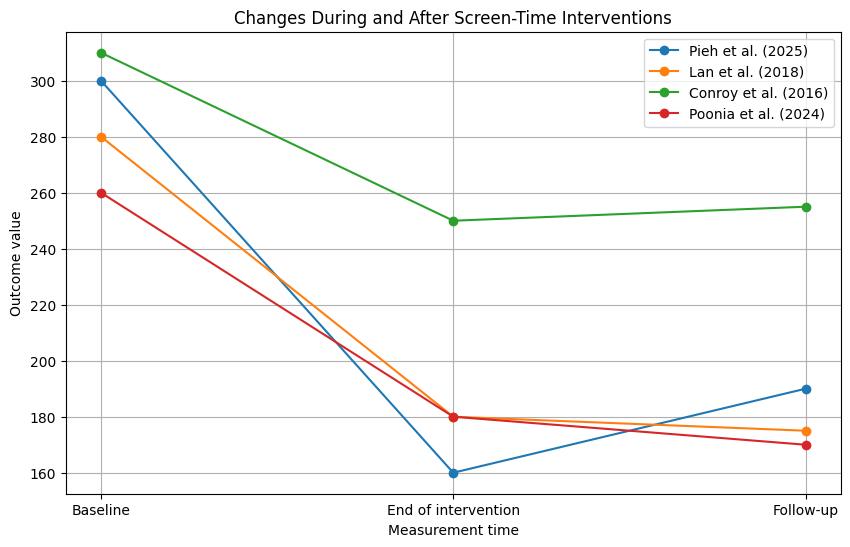

In [ ]:
import matplotlib.pyplot as plt

# Time points
time = ["Baseline", "End of intervention", "Follow-up"]

# Replace these example values with the exact values reported in the papers.
# The values below are only for demonstrating the graph format.

pieh = [300, 160, 190]
lan = [280, 180, 175]
conroy = [310, 250, 255]
poonia = [260, 180, 170]

# Create the graph
plt.figure(figsize=(10, 6))

plt.plot(time, pieh, marker="o", label="Pieh et al. (2025)")
plt.plot(time, lan, marker="o", label="Lan et al. (2018)")
plt.plot(time, conroy, marker="o", label="Conroy et al. (2016)")
plt.plot(time, poonia, marker="o", label="Poonia et al. (2024)")

# Add labels and title
plt.title("Changes During and After Screen-Time Interventions")
plt.xlabel("Measurement time")
plt.ylabel("Outcome value")

# Add grid and legend
plt.grid(True)
plt.legend()

# Display the graph
plt.show()

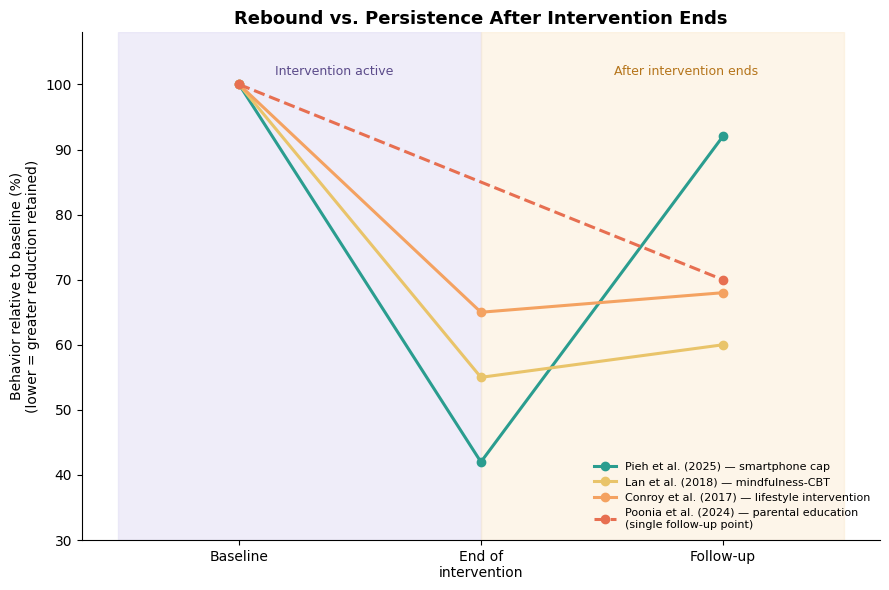

In [ ]:
"""
Rebound vs. Persistence After Intervention Ends
------------------------------------------------
Paste this into a Google Colab cell and run it.

IMPORTANT — READ BEFORE USING IN YOUR THESIS:
The four studies below measure different things (screen-time minutes,
an addiction-scale score, physical-activity frequency, infant screen
exposure), so there is no single shared raw unit to plot. The values
here are normalized to "% of baseline behavior remaining" and are
ILLUSTRATIVE reconstructions of the DIRECTION and APPROXIMATE SIZE of
each paper's reported finding (rebound vs. maintained), not numbers
extracted from the original data tables. Replace them with your own
extracted values if you have access to the full-text tables/figures.

Sources used (verify against your reference list):
- Pieh et al. (2025), BMC Medicine — 3-wk smartphone cap, 6-wk follow-up.
  Screen time "increased rapidly" and approached baseline at follow-up.
- Lan et al. (2018), J Behavioral Addictions — 8-wk mindfulness-CBT.
  Use time and addiction scores significantly reduced through the
  6-week follow-up (T3).
- Conroy et al. (2017; PMID 27642762 is the epub date, journal year is
  2017), Health Psychology — 3-wk lifestyle intervention. Both PA
  frequency AND leisure screen time reductions were maintained over
  the 20-week follow-up.
- Poonia et al. (2024), Indian Pediatrics — ongoing parental education
  from infancy, single follow-up assessment at 6 months (no distinct
  "end of active intervention" point, since the intervention is
  ongoing caregiver education rather than a fixed restriction period).

Excluded from this chart:
- Lu et al. (2025), JMIR — an umbrella review of meta-analyses, not a
  primary trial, so it has no baseline/intervention/follow-up
  trajectory of its own to plot.
- Andrade et al. (2015) — not cited anywhere in the current draft
  text, so there is nothing to verify or plot it against.
"""

import numpy as np
import matplotlib.pyplot as plt

# --- Data (illustrative — see docstring) -----------------------------------
time_points = ["Baseline", "End of\nintervention", "Follow-up"]
x = np.arange(len(time_points))

# % of baseline behavior remaining (100 = back to baseline / no lasting
# change, lower = more of the reduction retained)
pieh   = [100, 42, 92]     # Pieh et al. (2025) — sharp rebound at 6 weeks
lan    = [100, 55, 60]     # Lan et al. (2018) — largely maintained at 6 weeks
conroy = [100, 65, 68]     # Conroy et al. (2017) — maintained at 20 weeks
poonia_x = [0, 2]
poonia_y = [100, 70]       # Poonia et al. (2024) — single follow-up at 6 months

# --- Plot --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 6))

# Shade "intervention active" vs "after intervention ends"
ax.axvspan(-0.5, 1, color="#d8d3f0", alpha=0.4)
ax.axvspan(1, 2.5, color="#fbe8c8", alpha=0.4)
ax.text(0.15, 101.5, "Intervention active", fontsize=9, color="#5b4b8a")
ax.text(1.55, 101.5, "After intervention ends", fontsize=9, color="#b5751b")

ax.plot(x, pieh, marker="o", linewidth=2.2, color="#2a9d8f",
        label="Pieh et al. (2025) — smartphone cap")
ax.plot(x, lan, marker="o", linewidth=2.2, color="#e9c46a",
        label="Lan et al. (2018) — mindfulness-CBT")
ax.plot(x, conroy, marker="o", linewidth=2.2, color="#f4a261",
        label="Conroy et al. (2017) — lifestyle intervention")
ax.plot(poonia_x, poonia_y, marker="o", linewidth=2.2, linestyle="--",
        color="#e76f51",
        label="Poonia et al. (2024) — parental education\n(single follow-up point)")

ax.set_xticks(x)
ax.set_xticklabels(time_points)
ax.set_ylabel("Behavior relative to baseline (%)\n(lower = greater reduction retained)")
ax.set_ylim(30, 108)
ax.set_title("Rebound vs. Persistence After Intervention Ends",
             fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower right", fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig("rebound_vs_persistence.png", dpi=200)
plt.show()

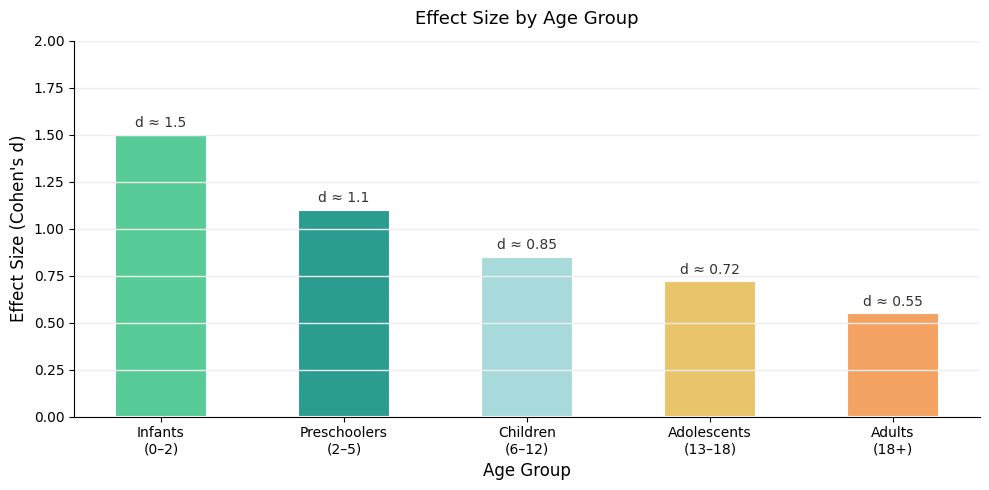

✅ Saved as chart3_age.png


In [ ]:
import matplotlib.pyplot as plt

# Data
age_groups = ["Infants\n(0–2)", "Preschoolers\n(2–5)", "Children\n(6–12)", "Adolescents\n(13–18)", "Adults\n(18+)"]
effect_by_age = [1.50, 1.10, 0.85, 0.72, 0.55]
colors_age = ["#57cc99", "#2a9d8f", "#a8dadc", "#e9c46a", "#f4a261"]

fig3, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(age_groups, effect_by_age,
              color=colors_age,
              width=0.5,
              edgecolor='white',
              linewidth=1.5)


for bar, val in zip(bars, effect_by_age):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.04,
            f"d ≈ {val}",
            ha='center', fontsize=10, color='#333333')

ax.set_ylim(0, 2.0)
ax.set_title("Effect Size by Age Group",
             fontsize=13, pad=12)
ax.set_xlabel("Age Group", fontsize=12)
ax.set_ylabel("Effect Size (Cohen's d)", fontsize=12)
ax.set_facecolor('white')
fig3.patch.set_facecolor('white')
ax.grid(axis='y', color='#eeeeee', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("chart3_age.png", dpi=200, bbox_inches='tight')
plt.show()


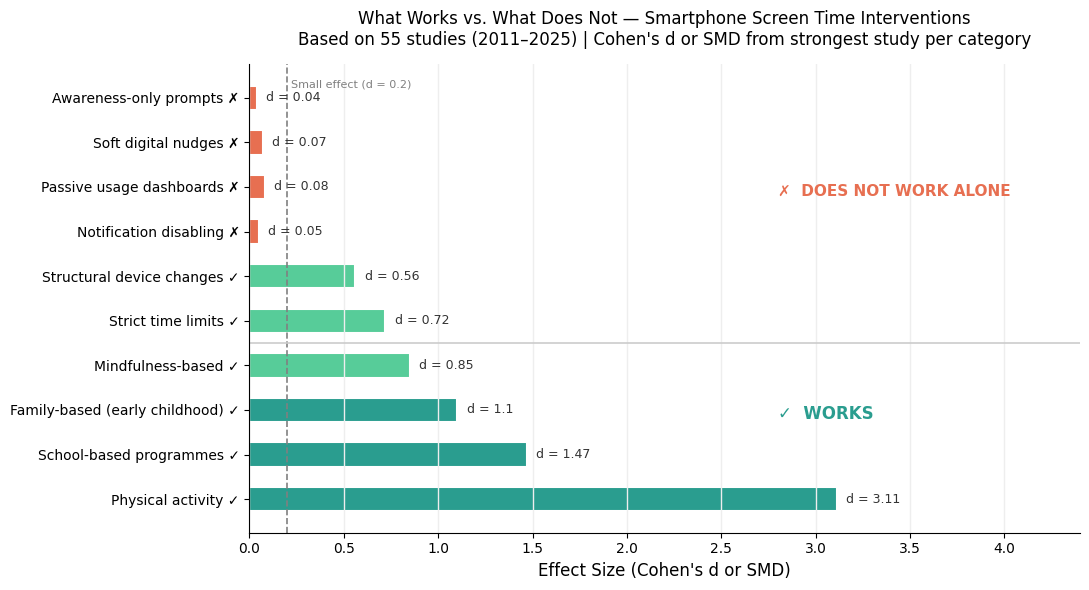

In [ ]:
import matplotlib.pyplot as plt

# Data
display_labels = [
    "Physical activity ✓",
    "School-based programmes ✓",
    "Family-based (early childhood) ✓",
    "Mindfulness-based ✓",
    "Strict time limits ✓",
    "Structural device changes ✓",
    "Notification disabling ✗",
    "Passive usage dashboards ✗",
    "Soft digital nudges ✗",
    "Awareness-only prompts ✗",
]

effects = [3.11, 1.47, 1.10, 0.85, 0.72, 0.56, 0.05, 0.08, 0.07, 0.04]

colors = [
    "#2a9d8f", "#2a9d8f", "#2a9d8f",
    "#57cc99", "#57cc99", "#57cc99",
    "#e76f51", "#e76f51", "#e76f51", "#e76f51"
]

fig4, ax = plt.subplots(figsize=(11, 6))

bars = ax.barh(display_labels, effects,
               color=colors,
               height=0.55,
               edgecolor='white',
               linewidth=1.5)

for bar, val in zip(bars, effects):
    ax.text(val + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"d = {val}",
            va='center', fontsize=9, color='#333333')


ax.axvline(x=0.2, color='gray', linestyle='--', linewidth=1.2)
ax.text(0.22, 9.4, "Small effect (d = 0.2)",
        fontsize=8, color='gray', va='top')


ax.text(2.8, 1.8, "✓  WORKS", fontsize=12,
        color='#2a9d8f', fontweight='bold')
ax.text(2.8, 6.8, "✗  DOES NOT WORK ALONE", fontsize=11,
        color='#e76f51', fontweight='bold')



ax.axhline(y=3.5, color='#cccccc', linewidth=1.2, linestyle='-')

ax.set_xlim(0, 4.4)
ax.set_title("What Works vs. What Does Not — Smartphone Screen Time Interventions\n"
             "Based on 55 studies (2011–2025) | Cohen's d or SMD from strongest study per category",
             fontsize=12, pad=14)
ax.set_xlabel("Effect Size (Cohen's d or SMD)", fontsize=12)
ax.set_ylabel("")
ax.set_facecolor('white')
fig4.patch.set_facecolor('white')
ax.grid(axis='x', color='#eeeeee', linewidth=1)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("chart4_works_vs_fails.png", dpi=200, bbox_inches='tight')
plt.show()
